In [ ]:
from pathlib import Path
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import torch

# Carga de datos

In [ ]:
def load_h5py_file(file_path):
    data = {
        "neural_features": [],
        "n_time_steps": [],
        "seq_class_ids": [],
        "seq_len": [],
        "transcriptions": [],
        "sentence_label": [],
        "session": [],
        "block_num": [],
        "trial_num": [],
    }
    with h5py.File(file_path, "r") as f:
        for key in list(f.keys()):
            g = f[key]

            neural_features = g["input_features"][:]
            n_time_steps = g.attrs["n_time_steps"]
            seq_class_ids = g["seq_class_ids"][:] if "seq_class_ids" in g else None
            seq_len = g.attrs["seq_len"] if "seq_len" in g.attrs else None
            transcription = g["transcription"][:] if "transcription" in g else None
            sentence_label = g.attrs["sentence_label"][:] if "sentence_label" in g.attrs else None
            session = g.attrs["session"]
            block_num = g.attrs["block_num"]
            trial_num = g.attrs["trial_num"]

            data["neural_features"].append(neural_features)
            data["n_time_steps"].append(n_time_steps)
            data["seq_class_ids"].append(seq_class_ids)
            data["seq_len"].append(seq_len)
            data["transcriptions"].append(transcription)
            data["sentence_label"].append(sentence_label)
            data["session"].append(session)
            data["block_num"].append(block_num)
            data["trial_num"].append(trial_num)
    return data

def _decode_if_bytes(x):
    if x is None:
        return None
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8", errors="replace")
    if isinstance(x, np.ndarray):
        if x.dtype == np.uint8:
            try:
                return bytes(x.tolist()).decode("utf-8", errors="replace")
            except Exception:
                return str(x)
        if x.dtype.kind in ("S", "O"):
            try:
                if x.ndim == 0:
                    return x.item().decode("utf-8", errors="replace")
                return b"".join(x.tolist()).decode("utf-8", errors="replace")
            except Exception:
                return str(x)
        return x
    return x

def infer_split_from_filename(name: str):
    name = name.lower()
    if "train" in name:
        return "train"
    if "val" in name or "valid" in name:
        return "val"
    if "test" in name:
        return "test"
    return None

def build_trials_df_from_root(
    root_dir: str,
    pattern: str = "*.hdf5",
    keep_arrays: bool = False
):
    root = Path(root_dir)
    h5_files = sorted(root.rglob(pattern))

    rows = []
    for fp in h5_files:
        split = infer_split_from_filename(fp.name)
        raw = load_h5py_file(str(fp))

        # 1 fila = 1 trial
        n = len(raw["session"])
        for i in range(n):
            nf = np.asarray(raw["neural_features"][i])
            row = {
                "file_path": str(fp),
                "session": raw["session"][i],
                "block_num": raw["block_num"][i],
                "trial_num": raw["trial_num"][i],
                "split": split,
                "n_time_steps": raw["n_time_steps"][i],
                "seq_len": raw["seq_len"][i],
                "sentence_label": _decode_if_bytes(raw["sentence_label"][i]),
                "transcription": _decode_if_bytes(raw["transcriptions"][i]),
                "neural_shape": nf.shape,
            }
            if keep_arrays:
                row["neural_features"] = raw["neural_features"][i]
                row["seq_class_ids"] = raw["seq_class_ids"][i]
            rows.append(row)

    return pd.DataFrame(rows)




# Ajusta este root al tuyo
df_trials = build_trials_df_from_root(r"PATH TO DATA", pattern="*.hdf5", keep_arrays=False)

## Nº de ensayos por sesión

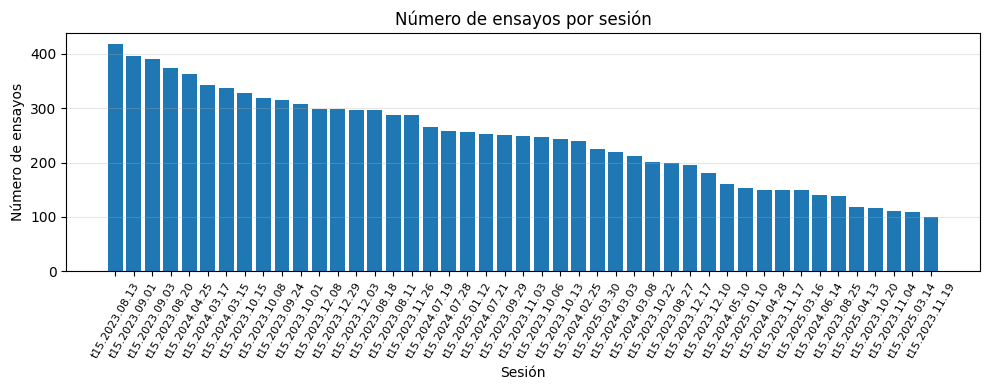

In [ ]:
df = df_trials.copy() # Dataset sin arrays de señal neuronal
session_counts = df["session"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(session_counts.index.astype(str), session_counts.values)
ax.set_title("Número de ensayos por sesión")
ax.set_xlabel("Sesión")
ax.set_ylabel("Número de ensayos")
ax.tick_params(axis="x", rotation=60, labelsize= 8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(
    "./img/numero_ensayos_por_sesion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:

def decode_transcription(x):
    if x is None:
        return None
    
    if isinstance(x, str):
        return x
    
    if isinstance(x, (list, tuple, np.ndarray)):
        try:
            arr = np.array(x).astype(int).tolist()
            return "".join(chr(v) for v in arr if v != 0)
        except Exception:
            return str(x)
    
    return str(x)

df["transcription_text"] = df["transcription"].apply(decode_transcription)

# Longitud textual en caracteres
df["char_len"] = df["sentence_label"].fillna(df["transcription_text"]).astype(str).str.len()

# Longitud temporal a partir de la columna explícita
df["input_len"] = df["n_time_steps"]

# Extraer T y D desde neural_shape
df["T_from_shape"] = df["neural_shape"].apply(lambda x: x[0] if isinstance(x, tuple) else None)
df["D_from_shape"] = df["neural_shape"].apply(lambda x: x[1] if isinstance(x, tuple) and len(x) > 1 else None)

# Longitud objetivo
df["target_len"] = df["seq_len"]

In [64]:
print(df[["input_len", "T_from_shape", "D_from_shape", "target_len", "char_len"]].head())
print(df["D_from_shape"].value_counts(dropna=False))
print((df["input_len"] == df["T_from_shape"]).mean())

   input_len  T_from_shape  D_from_shape  target_len  char_len
0        321           321           512        14.0        16
1        481           481           512        19.0        20
2        480           480           512        14.0        18
3        502           502           512        14.0        17
4        402           402           512        13.0        15
D_from_shape
512    10948
Name: count, dtype: int64
1.0


## Distribución de longitud temporal de entrada

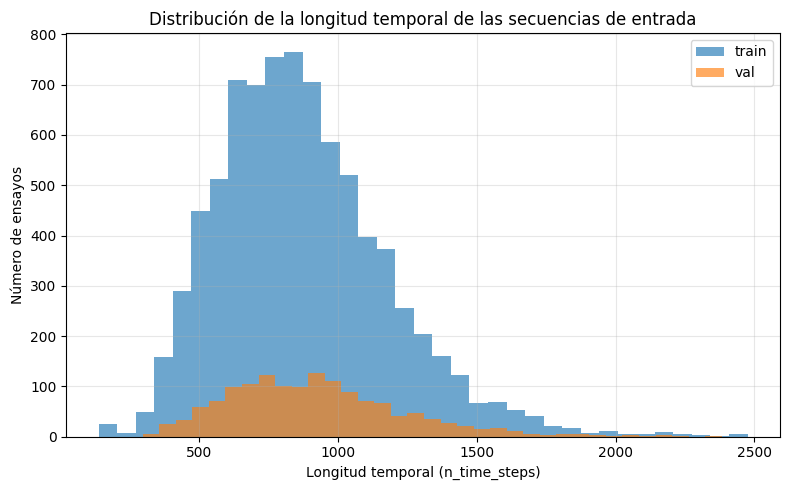

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

for split, alpha in [("train", 0.65), ("val", 0.65)]:
    subset = df[df["split"] == split]["input_len"].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=35, alpha=alpha, label=split)

ax.set_title("Distribución de la longitud temporal de las secuencias de entrada")
ax.set_xlabel("Longitud temporal (n_time_steps)")
ax.set_ylabel("Número de ensayos")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(
    "./img/distribucion_secuencias_entrada.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Longitud de objetivo en fonemas y caracteres

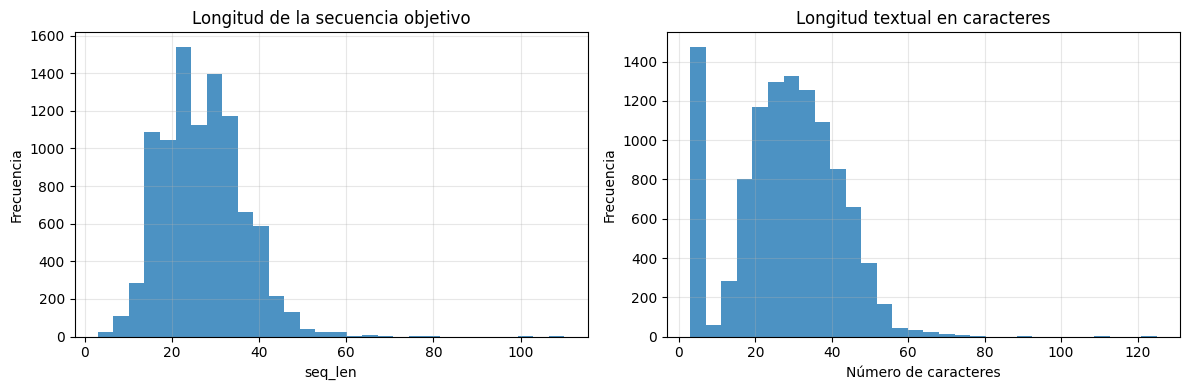

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Longitud de secuencia objetivo codificada
axes[0].hist(df["target_len"].dropna(), bins=30, alpha=0.8)
axes[0].set_title("Longitud de la secuencia objetivo")
axes[0].set_xlabel("seq_len")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.3)

# Longitud en caracteres
axes[1].hist(df["char_len"].dropna(), bins=30, alpha=0.8)
axes[1].set_title("Longitud textual en caracteres")
axes[1].set_xlabel("Número de caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(
    "./img/longitud_seq_objetivo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Relación entre longitud de entrada y objetivo

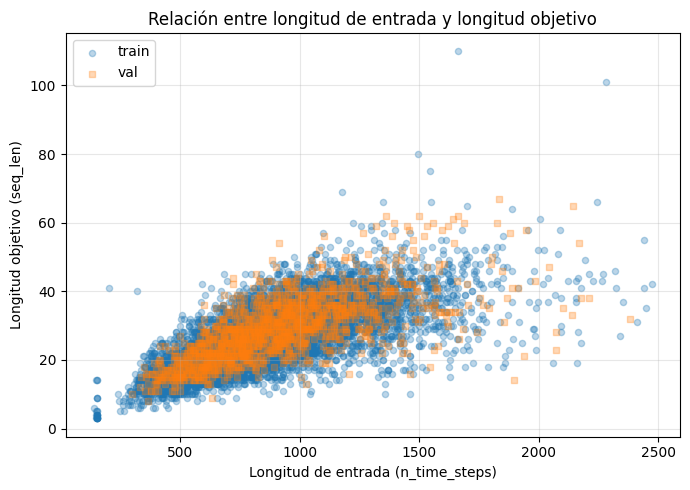

In [69]:
fig, ax = plt.subplots(figsize=(7, 5))

for split, marker in [("train", "o"), ("val", "s"), ("test", "^")]:
    subset = df[df["split"] == split].dropna(subset=["input_len", "target_len"])
    if len(subset) > 0:
        ax.scatter(
            subset["input_len"],
            subset["target_len"],
            alpha=0.3,
            s=20,
            label=split,
            marker=marker
        )

ax.set_title("Relación entre longitud de entrada y longitud objetivo")
ax.set_xlabel("Longitud de entrada (n_time_steps)")
ax.set_ylabel("Longitud objetivo (seq_len)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(
    "./img/relacion_entrada_y_objetivo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Representación de una señal de ejemplo

In [ ]:
# Cargar una señal de ejemplo
def load_signal_from_row(row):
    file_path = row["file_path"]
    target_session = row["session"]
    target_block = row["block_num"]
    target_trial = row["trial_num"]

    with h5py.File(file_path, "r") as f:
        for key in f.keys():
            g = f[key]

            session = g.attrs.get("session", None)
            block_num = g.attrs.get("block_num", None)
            trial_num = g.attrs.get("trial_num", None)

            # Normalización por si vienen en bytes
            if isinstance(session, bytes):
                session = session.decode()

            if session == target_session and block_num == target_block and trial_num == target_trial:
                signal = g["input_features"][:]
                return signal, key

    raise ValueError(
        f"No se encontró la muestra en el archivo.\n"
        f"session={target_session}, block={target_block}, trial={target_trial}"
    )

Muestra encontrada en clave HDF5: trial_0039
Shape señal: (741, 512)
Session: t15.2023.11.19 | Block: 2 | Trial: 39
Sentence: What do people think of me?


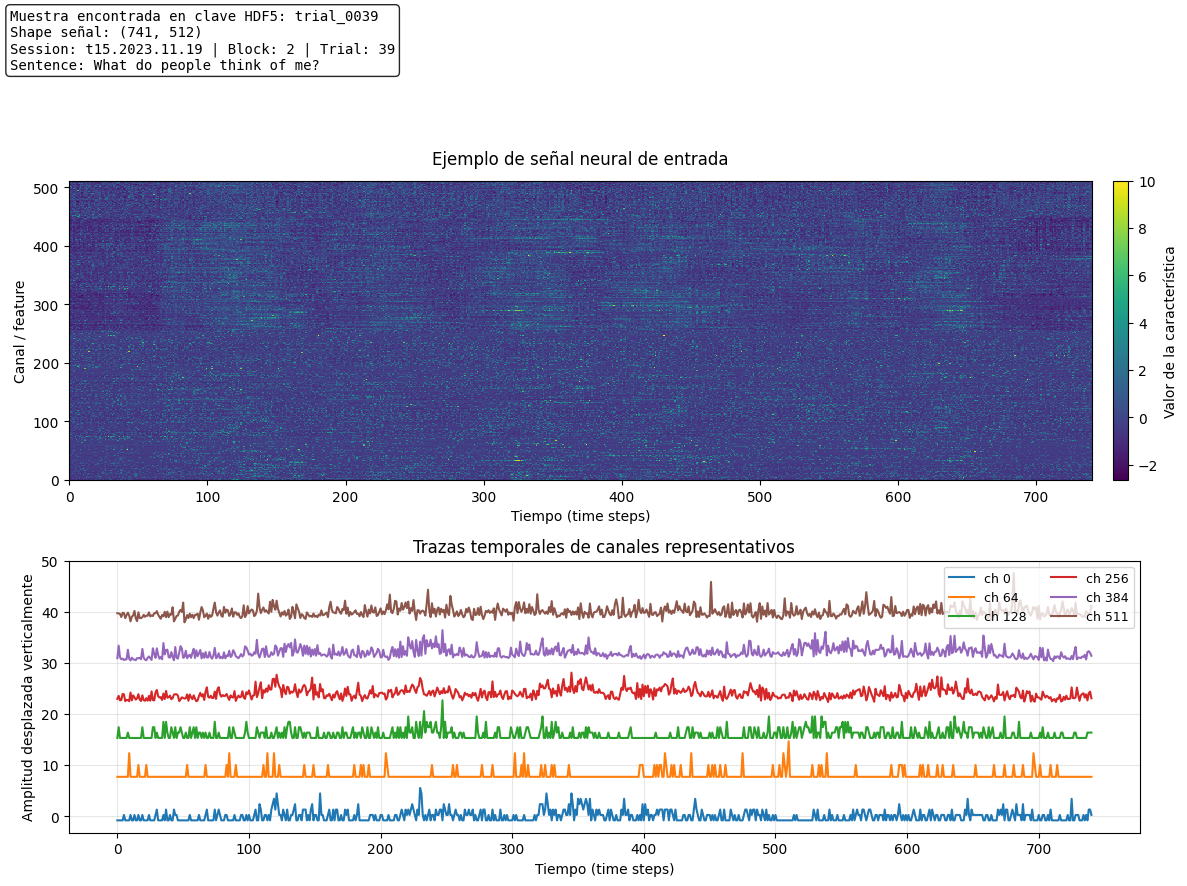

In [ ]:
# Selección de una muestra de ejemplo
example_row = (
    df[df["split"] == "train"]
    .iloc[len(df[df["split"] == "train"]) // 2]
)

signal, h5_key = load_signal_from_row(example_row)

# Texto informativo que antes salía con print
info_text = (
    f"Muestra encontrada en clave HDF5: {h5_key}\n"
    f"Shape señal: {signal.shape}\n"
    f"Session: {example_row['session']} | "
    f"Block: {example_row['block_num']} | "
    f"Trial: {example_row['trial_num']}\n"
    f"Sentence: {example_row['sentence_label']}"
)

print(info_text)

# Canales representativos
channels = [0, 64, 128, 256, 384, 511]
channels = [ch for ch in channels if ch < signal.shape[1]]

# Figura única con dos gráficos
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 9),
    gridspec_kw={"height_ratios": [1.1, 1]}
)

ax_heatmap = axes[0]
ax_traces = axes[1]

# Texto dentro de la figura
fig.text(
    0.01,
    0.98,
    info_text,
    ha="left",
    va="top",
    fontsize=10,
    family="monospace",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

# Heatmap de la señal completa
im = ax_heatmap.imshow(
    signal.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax_heatmap.set_title("Ejemplo de señal neural de entrada", pad=12)
ax_heatmap.set_xlabel("Tiempo (time steps)")
ax_heatmap.set_ylabel("Canal / feature")

cbar = fig.colorbar(im, ax=ax_heatmap, fraction=0.025, pad=0.02)
cbar.set_label("Valor de la característica")

# Trazas de algunos canales representativos
offset = 0.0

for ch in channels:
    x = signal[:, ch].astype(float)
    x = x - np.mean(x)
    ax_traces.plot(x + offset, label=f"ch {ch}")
    offset += 8.0

ax_traces.set_title("Trazas temporales de canales representativos")
ax_traces.set_xlabel("Tiempo (time steps)")
ax_traces.set_ylabel("Amplitud desplazada verticalmente")
ax_traces.legend(loc="upper right", ncol=2, fontsize=9)
ax_traces.grid(alpha=0.3)

# Deja espacio arriba para el bloque de texto
plt.tight_layout(rect=[0, 0, 1, 0.84])
fig.savefig(
    "./img/senal_neural_ejemplo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
example_row

file_path             \\wsl.localhost\Ubuntu\home\lucas\projects\nej...
session                                                  t15.2023.11.19
block_num                                                             2
trial_num                                                            39
split                                                             train
n_time_steps                                                        741
seq_len                                                            24.0
sentence_label                              What do people think of me?
transcription         [87, 104, 97, 116, 32, 100, 111, 32, 112, 101,...
neural_shape                                                 (741, 512)
transcription_text                          What do people think of me?
char_len                                                             27
input_len                                                           741
T_from_shape                                                    

In [ ]:
# Cargar dataset completo con arrays de señales neuronales

def _decode_scalar(x):
    """Convierte bytes y escalares numpy a tipos Python legibles."""
    if x is None:
        return None

    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8", errors="replace")

    if isinstance(x, np.generic):
        return x.item()

    return x


def _decode_array_or_scalar(x):
    """
    Intenta convertir objetos HDF5 a una representación legible:
    - strings/bytes -> str
    - arrays de bytes -> str o lista de str
    - arrays numéricos -> ndarray
    """
    if x is None:
        return None

    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8", errors="replace")

    if isinstance(x, np.ndarray):
        # escalar numpy envuelto
        if x.ndim == 0:
            return _decode_scalar(x.item())

        # array de uint8 que podría codificar texto
        if x.dtype == np.uint8:
            try:
                return bytes(x.tolist()).decode("utf-8", errors="replace")
            except Exception:
                return x

        # arrays de bytes/strings
        if x.dtype.kind in ("S", "U", "O"):
            try:
                out = []
                for item in x.tolist():
                    if isinstance(item, (bytes, np.bytes_)):
                        out.append(item.decode("utf-8", errors="replace"))
                    else:
                        out.append(item)
                return out
            except Exception:
                return x

        return x

    if isinstance(x, np.generic):
        return x.item()

    return x


def infer_split_from_filename(name: str):
    name = name.lower()
    if "train" in name:
        return "train"
    if "val" in name or "valid" in name:
        return "val"
    if "test" in name:
        return "test"
    return None


def summarize_value(value, keep_arrays=False, max_list_preview=10):
    """
    Devuelve una representación apropiada para DataFrame.
    - Si keep_arrays=True, conserva arrays.
    - Si keep_arrays=False, resume arrays grandes con shape/dtype.
    """
    value = _decode_array_or_scalar(value)

    if isinstance(value, np.ndarray):
        if keep_arrays:
            return value
        return {
            "_kind": "ndarray",
            "shape": tuple(value.shape),
            "dtype": str(value.dtype),
        }

    if isinstance(value, list):
        if keep_arrays:
            return value
        preview = value[:max_list_preview]
        return {
            "_kind": "list",
            "len": len(value),
            "preview": preview,
        }

    return value


def extract_group_to_row(
    group,
    file_path,
    file_name,
    split=None,
    include_root_attrs=None,
    include_root_datasets=None,
    keep_arrays=False,
    add_shape_fields=True,
):
    """
    Extrae todos los datasets y attrs de un grupo HDF5 a una fila.
    """
    row = {
        "file_path": str(file_path),
        "file_name": file_name,
        "split": split,
        "group_name": group.name,
    }

    # atributos del grupo
    for attr_name in group.attrs.keys():
        try:
            row[f"attr__{attr_name}"] = summarize_value(
                group.attrs[attr_name], keep_arrays=keep_arrays
            )
        except Exception as e:
            row[f"attr__{attr_name}"] = f"<ERROR_READING_ATTR: {e}>"

    # datasets/subgrupos del grupo
    for key in group.keys():
        obj = group[key]
        full_key = f"ds__{key}"

        try:
            if isinstance(obj, h5py.Dataset):
                value = obj[()]
                row[full_key] = summarize_value(value, keep_arrays=keep_arrays)

                if add_shape_fields:
                    row[f"{full_key}__shape"] = tuple(obj.shape)
                    row[f"{full_key}__dtype"] = str(obj.dtype)

            elif isinstance(obj, h5py.Group):
                row[full_key] = f"<SUBGROUP:{obj.name}>"
        except Exception as e:
            row[full_key] = f"<ERROR_READING_DATASET: {e}>"

    # opcional: attrs raíz
    if include_root_attrs:
        for attr_name, attr_value in include_root_attrs.items():
            row[f"root_attr__{attr_name}"] = summarize_value(
                attr_value, keep_arrays=keep_arrays
            )

    # opcional: datasets raíz
    if include_root_datasets:
        for ds_name, ds_value in include_root_datasets.items():
            row[f"root_ds__{ds_name}"] = summarize_value(
                ds_value, keep_arrays=keep_arrays
            )

    return row


def build_hdf5_dataframe(
    root_dir,
    pattern="*.hdf5",
    keep_arrays=False,
    include_root_level=True,
    recurse_groups=False,
):
    """
    Construye un DataFrame con todos los campos disponibles en archivos HDF5.

    Parámetros:
    - root_dir: carpeta raíz
    - pattern: patrón de búsqueda, por ejemplo '*.hdf5'
    - keep_arrays: si True conserva arrays completos; si False resume arrays
    - include_root_level: si True añade attrs y datasets de la raíz a cada fila
    - recurse_groups: si True recorre grupos anidados; si False solo primer nivel

    Devuelve:
    - DataFrame con una fila por grupo
    """
    root = Path(root_dir)
    h5_files = sorted(root.rglob(pattern))
    rows = []

    for fp in h5_files:
        split = infer_split_from_filename(fp.name)

        with h5py.File(fp, "r") as f:
            # attrs raíz
            root_attrs = {}
            root_datasets = {}

            if include_root_level:
                for attr_name in f.attrs.keys():
                    try:
                        root_attrs[attr_name] = f.attrs[attr_name]
                    except Exception as e:
                        root_attrs[attr_name] = f"<ERROR_READING_ROOT_ATTR: {e}>"

                for key in f.keys():
                    obj = f[key]
                    if isinstance(obj, h5py.Dataset):
                        try:
                            root_datasets[key] = obj[()]
                        except Exception as e:
                            root_datasets[key] = f"<ERROR_READING_ROOT_DATASET: {e}>"

            if recurse_groups:
                def visit_groups(name, obj):
                    if isinstance(obj, h5py.Group):
                        # evitamos meter la raíz como fila
                        if obj.name == "/":
                            return
                        rows.append(
                            extract_group_to_row(
                                obj,
                                file_path=fp,
                                file_name=fp.name,
                                split=split,
                                include_root_attrs=root_attrs if include_root_level else None,
                                include_root_datasets=root_datasets if include_root_level else None,
                                keep_arrays=keep_arrays,
                                add_shape_fields=True,
                            )
                        )

                f.visititems(visit_groups)

            else:
                # solo grupos de primer nivel
                for key in f.keys():
                    obj = f[key]
                    if isinstance(obj, h5py.Group):
                        rows.append(
                            extract_group_to_row(
                                obj,
                                file_path=fp,
                                file_name=fp.name,
                                split=split,
                                include_root_attrs=root_attrs if include_root_level else None,
                                include_root_datasets=root_datasets if include_root_level else None,
                                keep_arrays=keep_arrays,
                                add_shape_fields=True,
                            )
                        )

    return pd.DataFrame(rows)

In [ ]:
df_h5_full = build_hdf5_dataframe(
    root_dir=r"DATA PATH",
    pattern="*.hdf5",
    keep_arrays=True,
    include_root_level=True,
    recurse_groups=False,
)

In [56]:
df_h5_full

,file_path,file_name,split,group_name,attr__block_num,attr__n_time_steps,attr__sentence_label,attr__seq_len,attr__session,attr__trial_num,ds__input_features,ds__input_features__shape,ds__input_features__dtype,ds__seq_class_ids,ds__seq_class_ids__shape,ds__seq_class_ids__dtype,ds__transcription,ds__transcription__shape,ds__transcription__dtype
0,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_train.hdf5,train,/trial_0000,2,321,Bring it closer.,14.0,t15.2023.08.11,0,"[[2.3076649, -0.78699756, -0.64687246, -0.5465...","(321, 512)",float32,"[7, 28, 17, 24, 40, 17, 31, 40, 20, 21, 25, 29...","(500,)",int32,"[66, 114, 105, 110, 103, 32, 105, 116, 32, 99,...","(500,)",int32
1,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_train.hdf5,train,/trial_0001,2,481,My family is closer.,19.0,t15.2023.08.11,1,"[[-0.51709145, -0.70207363, -0.64330804, -0.48...","(481, 512)",float32,"[22, 6, 40, 14, 2, 22, 3, 21, 18, 40, 17, 38, ...","(500,)",int32,"[77, 121, 32, 102, 97, 109, 105, 108, 121, 32,...","(500,)",int32
2,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_train.hdf5,train,/trial_0002,2,480,What do they like?,14.0,t15.2023.08.11,2,"[[0.95464545, -0.6912571, 2.5334082, -0.459320...","(480, 512)",float32,"[36, 3, 31, 40, 9, 34, 40, 10, 13, 40, 21, 6, ...","(500,)",int32,"[87, 104, 97, 116, 32, 100, 111, 32, 116, 104,...","(500,)",int32
3,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_train.hdf5,train,/trial_0003,2,502,How is that good?,14.0,t15.2023.08.11,3,"[[-0.4997814, -0.6836047, -0.6305947, 1.260037...","(502, 512)",float32,"[16, 5, 40, 17, 38, 40, 10, 2, 31, 40, 15, 33,...","(500,)",int32,"[72, 111, 119, 32, 105, 115, 32, 116, 104, 97,...","(500,)",int32
4,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_train.hdf5,train,/trial_0004,2,402,Need help here?,13.0,t15.2023.08.11,4,"[[-0.4850082, -0.66607094, -0.62398034, -0.433...","(402, 512)",float32,"[23, 18, 9, 40, 16, 11, 21, 27, 40, 16, 18, 28...","(500,)",int32,"[78, 101, 101, 100, 32, 104, 101, 108, 112, 32...","(500,)",int32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10943,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_val.hdf5,val,/trial_0020,8,995,What if you were in your kid's shoes?,29.0,t15.2025.04.13,20,"[[-0.32311952, 0.7297157, 3.071861, -0.4787033...","(995, 512)",float32,"[36, 3, 31, 40, 17, 14, 40, 37, 34, 40, 36, 12...","(500,)",int32,"[87, 104, 97, 116, 32, 105, 102, 32, 121, 111,...","(500,)",int32
10944,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_val.hdf5,val,/trial_0021,8,794,I don't know if you've tried it.,25.0,t15.2025.04.13,21,"[[-0.31448692, -0.5990613, -0.6263106, -0.4706...","(794, 512)",float32,"[6, 40, 9, 25, 23, 31, 40, 23, 25, 40, 17, 14,...","(500,)",int32,"[73, 32, 100, 111, 110, 39, 116, 32, 107, 110,...","(500,)",int32
10945,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_val.hdf5,val,/trial_0022,8,1183,Barometric pressure drops during a tornado.,39.0,t15.2025.04.13,22,"[[-0.30280015, 0.73466504, 0.6293097, -0.46393...","(1183, 512)",float32,"[7, 2, 28, 3, 22, 11, 31, 28, 17, 20, 40, 27, ...","(500,)",int32,"[66, 97, 114, 111, 109, 101, 116, 114, 105, 99...","(500,)",int32
10946,\\wsl.localhost\Ubuntu\home\lucas\projects\nej...,data_val.hdf5,val,/trial_0023,8,1142,Cover him up and keep him warm.,29.0,t15.2025.04.13,23,"[[-0.3079747, -0.613724, -0.62444085, -0.47084...","(1142, 512)",float32,"[20, 3, 35, 12, 40, 16, 17, 22, 40, 3, 27, 40,...","(500,)",int32,"[67, 111, 118, 101, 114, 32, 104, 105, 109, 32...","(500,)",int32


In [21]:
df_h5_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10948 entries, 0 to 10947
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   file_path                  10948 non-null  object 
 1   file_name                  10948 non-null  object 
 2   split                      10948 non-null  object 
 3   group_name                 10948 non-null  object 
 4   attr__block_num            10948 non-null  int64  
 5   attr__n_time_steps         10948 non-null  int64  
 6   attr__sentence_label       9498 non-null   object 
 7   attr__seq_len              9498 non-null   float64
 8   attr__session              10948 non-null  object 
 9   attr__trial_num            10948 non-null  int64  
 10  ds__input_features         10948 non-null  object 
 11  ds__input_features__shape  10948 non-null  object 
 12  ds__input_features__dtype  10948 non-null  object 
 13  ds__seq_class_ids          9498 non-null   obj

In [22]:
df_h5_full.describe()

,attr__block_num,attr__n_time_steps,attr__seq_len,attr__trial_num
count,10948.000000,10948.000000,9498.000000,10948.000000
mean,5.149251,886.527037,26.914719,22.651443
std,2.964362,308.407073,9.217328,14.377913
min,1.000000,138.000000,3.000000,0.000000
25%,3.000000,664.000000,20.000000,10.000000
50%,5.000000,850.000000,26.000000,22.000000
75%,7.000000,1061.000000,33.000000,35.000000
max,14.000000,2475.000000,110.000000,59.000000


## Estabilidad de señal por sesión

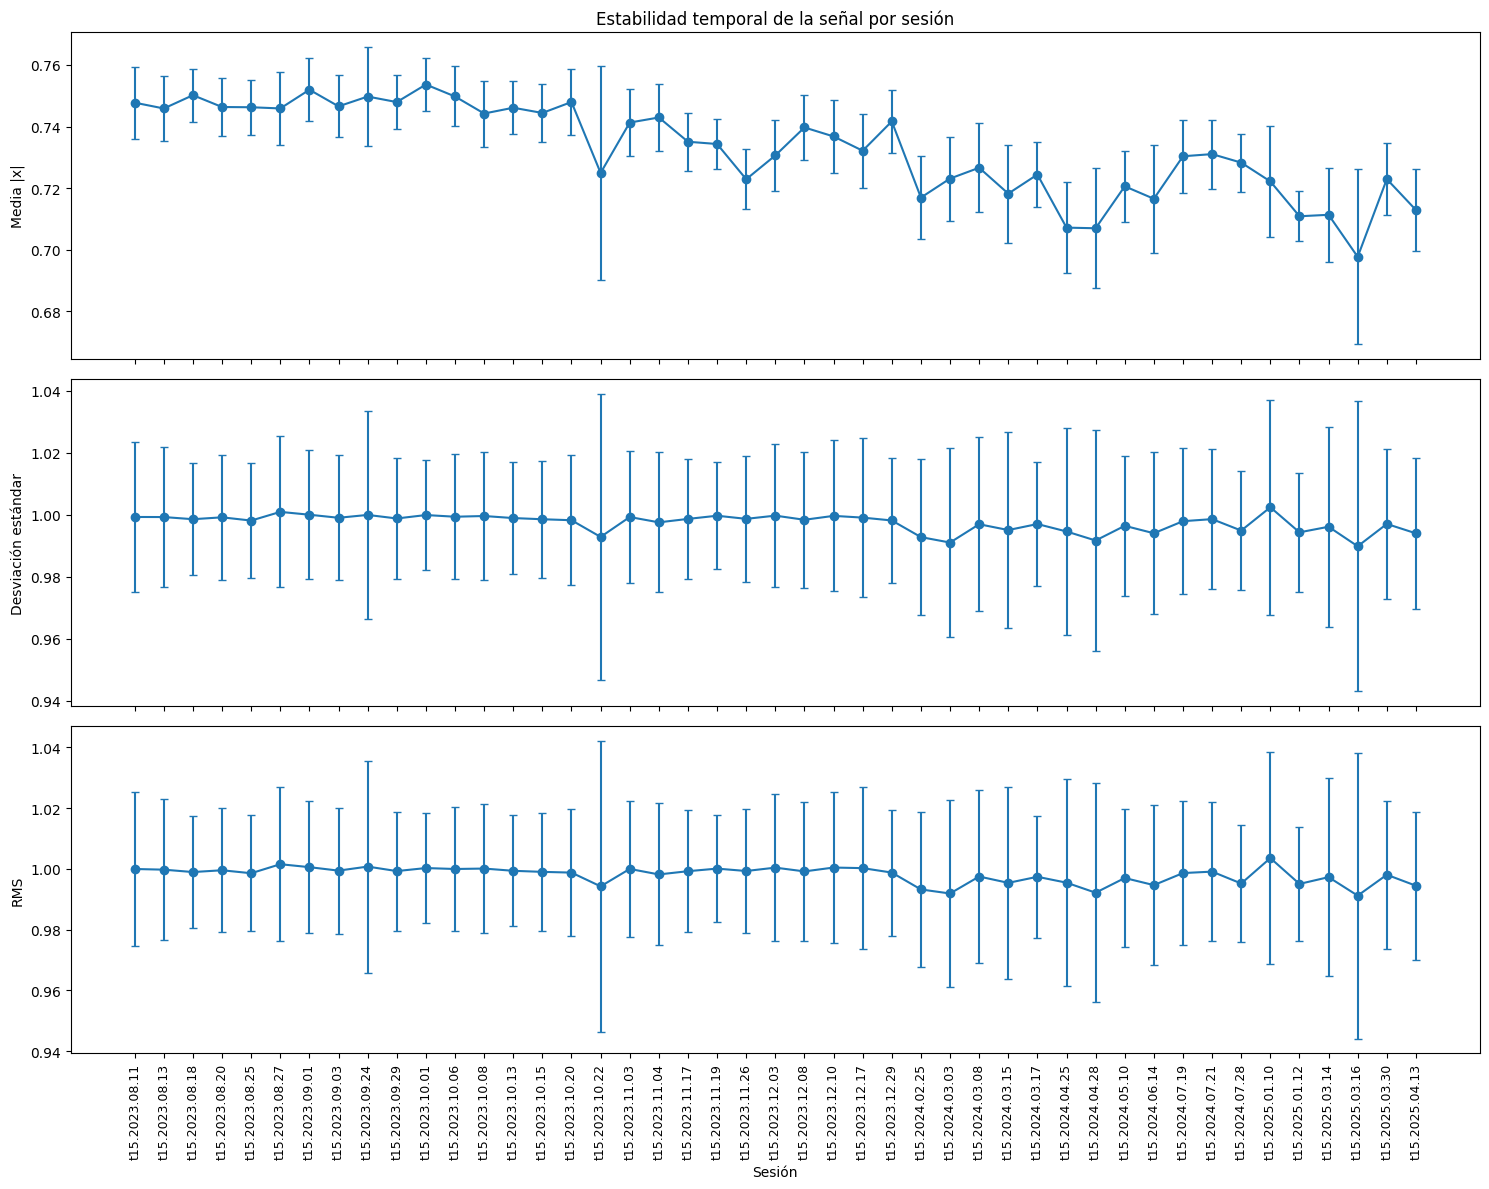

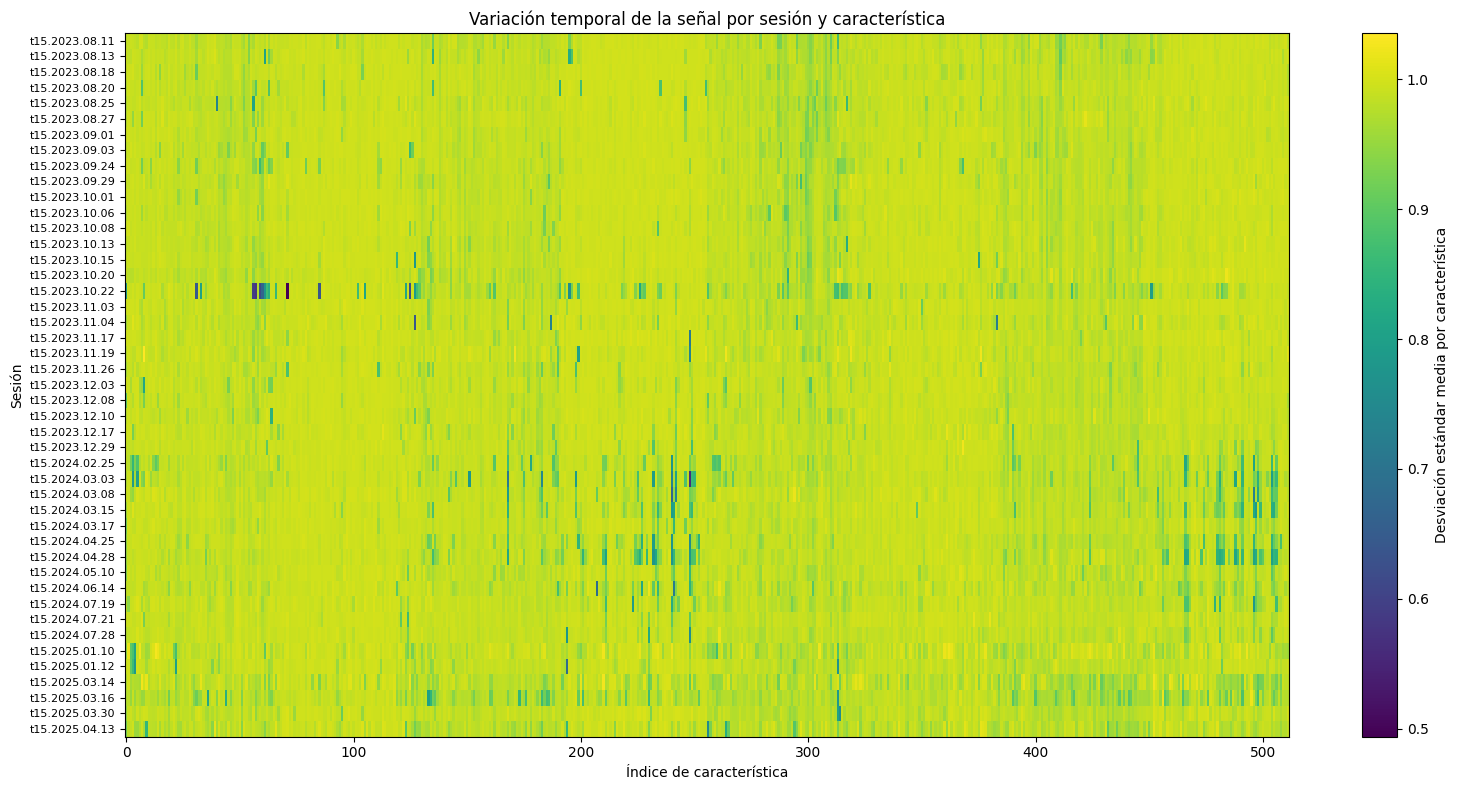

In [ ]:
#  Preparación de métricas por ensayo

def add_signal_stability_metrics(df, input_col="ds__input_features"):
    df = df.copy()

    mean_abs = []
    global_std = []
    global_rms = []

    for x in df[input_col]:
        arr = np.asarray(x, dtype=np.float32)

        mean_abs.append(np.mean(np.abs(arr)))
        global_std.append(np.std(arr))
        global_rms.append(np.sqrt(np.mean(arr ** 2)))

    df["signal_mean_abs"] = mean_abs
    df["signal_std"] = global_std
    df["signal_rms"] = global_rms

    return df


# Resumen por sesión

def summarize_signal_by_session(df, session_col="attr__session"):
    summary = (
        df.groupby(session_col)
        .agg(
            n_trials=("group_name", "count"),
            mean_abs_mean=("signal_mean_abs", "mean"),
            mean_abs_std=("signal_mean_abs", "std"),
            signal_std_mean=("signal_std", "mean"),
            signal_std_std=("signal_std", "std"),
            signal_rms_mean=("signal_rms", "mean"),
            signal_rms_std=("signal_rms", "std"),
        )
        .reset_index()
    )

    return summary


# Orden temporal de sesiones

def sort_session_labels(session_labels):
    """
    Ordena etiquetas tipo 't15.2023.08.11' por fecha.
    Si no puede parsear, las deja en orden alfabético.
    """
    def session_to_datetime(s):
        try:
            # espera algo como t15.2023.08.11
            parts = str(s).split(".")
            # ['t15', '2023', '08', '11']
            year = int(parts[1])
            month = int(parts[2])
            day = int(parts[3])
            return pd.Timestamp(year=year, month=month, day=day)
        except Exception:
            return pd.NaT

    tmp = pd.DataFrame({"session": session_labels})
    tmp["dt"] = tmp["session"].map(session_to_datetime)

    if tmp["dt"].notna().all():
        tmp = tmp.sort_values("dt")
    else:
        tmp = tmp.sort_values("session")

    return tmp["session"].tolist()



# Figura 1: métricas globales por sesión

def plot_signal_stability_by_session(summary_df, session_col="attr__session"):
    summary_df = summary_df.copy()

    ordered_sessions = sort_session_labels(summary_df[session_col].tolist())
    summary_df["session_order"] = pd.Categorical(
        summary_df[session_col],
        categories=ordered_sessions,
        ordered=True
    )
    summary_df = summary_df.sort_values("session_order")

    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

    # Media del valor absoluto
    axes[0].errorbar(
        summary_df[session_col],
        summary_df["mean_abs_mean"],
        yerr=summary_df["mean_abs_std"],
        fmt="-o",
        capsize=3
    )
    axes[0].set_title("Estabilidad temporal de la señal por sesión")
    axes[0].set_ylabel("Media |x|")

    # Desviación estándar
    axes[1].errorbar(
        summary_df[session_col],
        summary_df["signal_std_mean"],
        yerr=summary_df["signal_std_std"],
        fmt="-o",
        capsize=3
    )
    axes[1].set_ylabel("Desviación estándar")

    # RMS
    axes[2].errorbar(
        summary_df[session_col],
        summary_df["signal_rms_mean"],
        yerr=summary_df["signal_rms_std"],
        fmt="-o",
        capsize=3
    )
    axes[2].set_ylabel("RMS")
    axes[2].set_xlabel("Sesión")

    plt.xticks(rotation=90, fontsize=9)
    plt.tight_layout()
    fig.savefig(
    "./img/desviacion_señal_tiempo.png",
    dpi=300,
    bbox_inches="tight")
    plt.show()

# Heatmap sesión × característica

def compute_feature_std_by_session(df, input_col="ds__input_features", session_col="attr__session"):
    """
    Para cada ensayo:
      - calcula std temporal por característica
    Después:
      - promedia por sesión
    Devuelve DataFrame con filas=sesión y columnas=features
    """
    rows = []

    for _, row in df.iterrows():
        x = np.asarray(row[input_col], dtype=np.float32)   # shape [T, 512]
        feat_std = np.std(x, axis=0)                       # shape [512]

        rows.append(
            pd.DataFrame(
                {
                    "session": row[session_col],
                    "feature_idx": np.arange(len(feat_std)),
                    "feature_std": feat_std
                }
            )
        )

    tmp = pd.concat(rows, ignore_index=True)

    heat = (
        tmp.groupby(["session", "feature_idx"])["feature_std"]
        .mean()
        .unstack("feature_idx")
    )

    ordered_sessions = sort_session_labels(heat.index.tolist())
    heat = heat.loc[ordered_sessions]

    return heat


def plot_feature_std_heatmap(heat_df):
    plt.figure(figsize=(16, 8))
    plt.imshow(heat_df.values, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Desviación estándar media por característica")
    plt.yticks(np.arange(len(heat_df.index)), heat_df.index, fontsize=8)
    plt.xlabel("Índice de característica")
    plt.ylabel("Sesión")
    plt.title("Variación temporal de la señal por sesión y característica")
    plt.tight_layout()
    plt.savefig(
    "./img/variacion_temporal_por_caracteristica.png",
    dpi=300,
    bbox_inches="tight")
    plt.show()



#  Uso:
# df_h5_full debe contener los arrays completos en ds__input_features
# generado con keep_arrays=True

# Añadir métricas por ensayo
df_signal = add_signal_stability_metrics(df_h5_full, input_col="ds__input_features")

# Resumen por sesión
summary_signal = summarize_signal_by_session(df_signal, session_col="attr__session")

# Figura global por sesión
plot_signal_stability_by_session(summary_signal, session_col="attr__session")

# Heatmap opcional
heat_feature_std = compute_feature_std_by_session(
    df_signal,
    input_col="ds__input_features",
    session_col="attr__session"
)
plot_feature_std_heatmap(heat_feature_std)

## Comparación de señal antes y después de aplicar suavizado gaussiano

In [ ]:
def plot_gaussian_smoothing_simple(
    df,
    trial_idx=0,
    input_col="ds__input_features",
    smooth_kernel_std=2.0,
    smooth_kernel_size=11,
    selected_features=(0, 8, 32),
    save_path=None,
):
    row = df.iloc[trial_idx]
    x = np.asarray(row[input_col], dtype=np.float32)

    x_torch = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    x_smooth = gauss_smooth(
        inputs=x_torch,
        device=torch.device("cpu"),
        smooth_kernel_std=smooth_kernel_std,
        smooth_kernel_size=smooth_kernel_size,
    ).squeeze(0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(15, 6))

    for f in selected_features:
        ax.plot(x[:, f], alpha=0.35, linewidth=1, label=f"Original f{f}")
        ax.plot(x_smooth[:, f], linewidth=2, label=f"Suavizada f{f}")

    ax.set_title("Comparación antes y después del suavizado gaussiano")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    ax.legend(ncol=2, fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return x, x_smooth

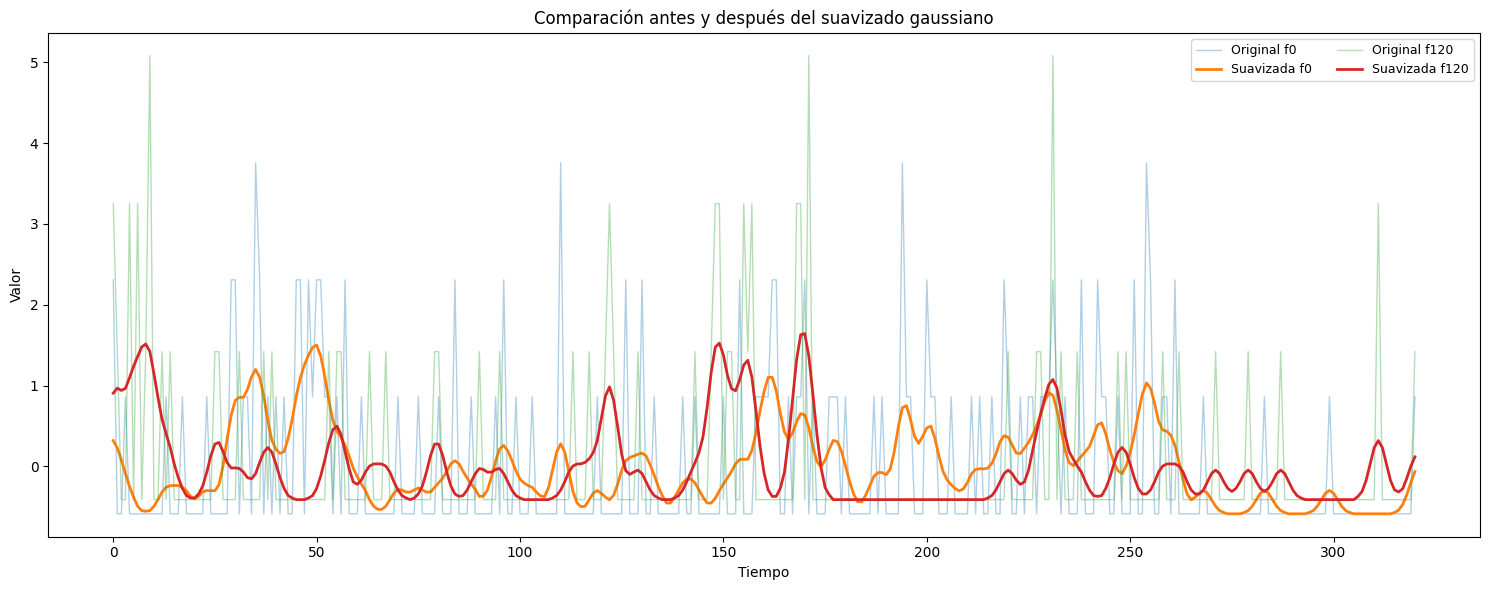

In [ ]:
from data_augmentations import gauss_smooth # data_augmentations se encuentra en las utilidades dentro de /experiments/RAMA/MODELO, mismo preprocesado que se aplica en Train
x_orig, x_smooth = plot_gaussian_smoothing_simple(
    df=df_h5_full,
    trial_idx=0,
    input_col="ds__input_features",
    smooth_kernel_std=2.0,
    smooth_kernel_size=11,
    selected_features=(0, 120),
    save_path="./img/suavizado_gaussiano_ejemplo.png"
)